## #1 ##

In [3]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.feature_extraction import text as sktext

raw_sentences = [
    # Great Gatsby essay
    "Embodying the era's amoral ethos, F. Scott Fitzgerald's Daisy proves far more complex, cunning, and realistic than the damsel in distress Jay Gatsby imagines.",
    "A conversational chameleon, she artfully deploys language as part of a charm offensive, deftly spinning together phrases that exude wit, style, and vulnerability.",
    "However, this pretense of girlish vivacity belies a darker self, one defined by her self-loathing, cynicism, and cowardice.",
    "Daisy's linguistic artifice ultimately makes her more dangerous than Miguel de Cervantes's windmills as Gatsby, a Jazz Age Quixotic hero, risks the ruin of his spirit, not just his body, in pursuit of her.",
    "Nick remarks on Daisy's charisma during their reunion, likening her to a siren, albeit a mostly good-humored one without any trace of malice.",
    "He notes her low, thrilling voice that plays like a hypnotic melody.",
    "There was an excitement in her voice that men who had cared for her found difficult to forget.",
    "Shortly after exchanging pleasantries, however, Daisy's demeanor shifts decidedly from pleasantly frivolous to bitingly sardonic.",
    "Nick's mention of Gatsby and Tom's pseudointellectual racist buffoonery appears to catalyze this change.",
    "Perhaps already keen to Nick's animus towards Tom, she makes barbed remarks, referring to her husband as a brute of a man.",
    "While never outright breaching rules of etiquette, Daisy's jests transmit signals to Nick that draw him immediately into a confidential relationship.",
    "This relationship appears based upon a shared aversion for Tom, and not kinship ties alone.",
    "Speaking privately with Nick on the patio, Daisy sheds her skin to reveal a new one.",
    "She reveals that of a woman so disillusioned and defeated she cannot conceive her infant daughter having a bright future.",
    "She then mocks the elitism and privilege that gild her life, remarking God, I'm sophisticated.",
    "In keeping with her role as a siren, Daisy uses language like a strip tease to compel Nick's attention.",
    "This baring of dirty secrets muddies his impression of her once silence sets in.",
    "Nick's keen personal insight admits the possibility of Daisy using language in much the same way Tom uses his physique, to dominate.",
    "Nevertheless, Fitzgerald's narrator plays a critical role reuniting her with Gatsby.",
    "His apprehension foreshadows the conspiracy that dooms Jay.",
    "Daisy skillfully wields language towards straddling and commanding her affair with Jay and her marriage to Tom.",
    "With respect to the former, she adopts a sweet, girlish disposition that mollifies Jay's initial shyness at their reunion.",
    "According to Nick, he is behaving like a little boy at their reunion.",
    "During their tour of Gatsby's mansion, she revels in his desire to impress her, making enchanting murmurs that appear largely performative.",
    "Seeming to regress to the teenage sweetheart from Louisville, Daisy's acting crescendos with a melodramatic paroxysm of joy.",
    "She begins sobbing while remarking on Jay's attire, saying it makes her sad because she has never seen such beautiful shirts before.",
    "By drawing this implicit comparison to Tom and playing the part of the wonderstruck girl, Daisy signals her capacity to read people.",
    "Notably, her demeanor proves far less effusive when she first encounters Gatsby at Nick's.",
    "Keenly aware of his insecurities and hopes after their private talk, she thereafter uses language to coax Jay.",
    "She indulges his dream by clearly signaling her desire to consume his love.",
    "In stark contrast to this saccharine display, Daisy jousts verbally with Tom, using Jay as a lance to knock her husband off his high horse.",
    "In response to Tom's snide remarks about Jay and the society he keeps at his parties, Daisy proclaims they are more interesting than the people they know.",
    "She hits back at Tom's outspoken suspicions by presenting Jay as a gallant self-made man.",
    "Daisy seeks to weaponize Jay by presenting him as Tom's foil.",
    "This effort to humiliate Tom not only highlights Daisy's vindictiveness, but also her disingenuousness and desperation.",
    "Nick exposes chinks in her armor by indicating that she defends Gatsby's friends with effort.",
    "Whereas Gatsby intends for the party to wean Daisy from Tom, ultimately the event reinforces distinctions between West Egg and East Egg.",
    "The event also reinforces distinctions between new money and old money, and between the quixotic Jay and the realist Daisy.",
    "Whereas Daisy can employ language to charm others like a siren, she also uses this same power to defend against threats like a chameleon.",
    "In the novel's climactic confrontation between Jay and Tom at the Plaza Hotel, Daisy's allegiance to Gatsby shifts completely.",
    "She perceives his criminality a graver threat to her status and reputation than Tom's adultery.",
    "Daisy's change in tone, from incensed to indecisive, reflects a shift in her personality from active to passive.",
    "At the scene's outset, Daisy's affair with Gatsby still serves as a source of personal empowerment.",
    "Leveraging the possibility of a brighter future with Jay, she sharpens her attacks against Tom, each one more blistering than the one before.",
    "She chides him for clumsily questioning Gatsby's Oxford credentials.",
    "Upon seeing her husband increasingly incensed, she addresses him as she would a whiny infant.",
    "In reference to Tom's little spree of affairs, she calls him revolting.",
    "Signaling a shift in her tone, Nick notes this rancor was gone, neutralized by Tom's parading of innuendos.",
    "She thereafter wields her timidity as a shield when, while feeling pressure to account for her relationships with both men, she exclaims to Jay that she loves him now.",
    "She assumes the role of victim, her rhetorical question recasting Gatsby as the tyrant who wants too much.",
    "Aware that she is shedding her skin, Tom seizes the opportunity to deliver the coup de grace.",
    "He discloses Jay's bootlegging while alluding to other nefarious activities.",
    "Daisy's mask of sophistication slips off entirely as she stares terrified between Gatsby and her husband.",
    "Wishing for this nightmare to end, Daisy chooses the devil she knows over the devil she doesn't.",
    "She resists Gatsby's efforts to keep the dream of happiness together alive by drawing further and further into herself.",
    "She has transformed back into Tom's Daisy, the frightened, put-upon wife eager to return to her mansion in East Egg.",
    "While the prospect of seizing a new destiny tempts her, she ultimately retreats.",
    "She is unwilling to take the risks, to step out upon the ice as Gatsby had in his pursuit of her.",
    "In his last scene featuring the character Daisy, Fitzgerald omits her voice completely to focus on her demeanor and body language.",
    "The reader, via Nick, observes her betrayal of Jay voyeuristically, through the window of the Buchanan mansion.",
    "She allows Tom's hand to cover her own and intermittently looks up at him and nods in agreement as he plots their travel abroad.",
    "Without the cover of language, Nick and the reader more clearly see the natural intimacy of Daisy and Tom's relationship.",
    "They see the obviousness by which they were conspiring together.",
    "Nick cynically concedes that Jay is watching over nothing when standing guard nearby.",
    "Nick proves more explicit in his condemnation when remarking they were careless people, Tom and Daisy.",
    "Gatsby, deluded by the desire to relive the past in the present, cares too much about a woman who cares too little.",
    "She cannot bother to call him before he unwittingly winds up taking a bullet for her in the pool.",
    # Contemporary Triptych
    "I regret to inform you that YOUNG JAE WON will not be extending Louis an invitation to enroll in next year's classes.",
    "Based on our scrupulous observations of your son's performance throughout the Fall and Spring terms, I have concluded Louis is not a proper fit for our institution.",
    "A cornerstone of early arts education since the birth of modern Korea, YOUNG JAE WON is a selective institution for gifted students in the visual arts.",
    "Founded on a legacy of rigorous instruction and cultural stewardship, our mission is to develop promising young talents into disciplined, capable artists.",
    "While your son has demonstrated a natural predisposition towards the arts and appears to enjoy applying his efforts to creative assignments, he invariably fails to follow instructions closely.",
    "This not only undermines his own advancement but distracts peers from their own.",
    "Truth be told, Louis's exclusion from the next school year distresses me on a personal level.",
    "I occupy the positions of both teacher and administrator.",
    "I intermittently encounter situations wherein I must balance the demands of a classroom student against those of YOUNG JAE WON's sterling reputation.",
    "Art celebrates beauty according to the first principle of our institution.",
    "Our class esteems Alfred de Vigny's precept that art ought never to be considered except in its relation with its ideal beauty.",
    "We study the Renaissance masters whose works reflect the divine in their harmony.",
    "This tradition values proportion, form, and precision.",
    "A lotus flower, properly rendered, is not just a botanical object; it is a meditation on grace.",
    "However, your son instead chooses to focus on ugliness.",
    "One of Louis's recent portraits featured a titular man with black streaks slapped across his frame.",
    "Art serves resistance according to the second principle of our institution.",
    "As post-impressionist painter Paul Gauguin observed, art is either plagiarism or revolution.",
    "We expect our students to adopt a critical eye when viewing the larger world.",
    "From Goya to Picasso, artists have wielded their tools to confront social injustice and challenge the status quo.",
    "However, your son instead chooses to focus on the internal, not external world.",
    "His artwork is littered with bizarre shadowy figures and impenetrable mandalas that evoke Jungian psychology.",
    "Art yields revelation according to the third principle of our institution.",
    "Novelist Flannery O'Connor determined that the basis of art is truth, both in matter and in mode.",
    "This principle inspires our class's efforts to imitate quiet, insightful works grounded in realism.",
    "This tradition encourages artists to pause, to observe the world faithfully towards revealing truth.",
    "However, your son instead chooses to deepen the mystery.",
    "Louis's shadowy figure, with its unrealistic proportions, reveals very little except perhaps his own unwavering commitment to obscurity.",
    "These three conceptions of art inform the collective work of YOUNG JAE WON's students and alumni.",
    "While I have continuously endeavored to mentor Louis, to nudge him into line with the others, my efforts as teacher have proven in vain.",
    "During a recent critique, Louis submitted a deliberately unattractive piece titled I Knew I Was Lying When I Drew the Apple.",
    "Rather than demonstrate his proficiency in line weight, composition, or tonal control, Louis's canvas consisted of smudged figures dissolving into scribbled charcoal.",
    "Phrases were scrawled across the canvas in unintelligible languages.",
    "Centrally, a horrific eye was drawn inside a cracked mirror.",
    "This piece, like many of his earlier ones, focused on ugliness instead of beauty.",
    "It indulged in the internal world rather than critically examining the external one.",
    "When asked to explain his motivation, Louis responded that he does not want to make art for the world to consume.",
    "He wants to make art that brings harmony to him.",
    "Needless to say, Louis's attitude, like this artwork, has proven remarkably unmarketable.",
    "Shortly thereafter I advised Louis that his artistic process echoed the Minjung movement of the 1980s.",
    "It was a well-intentioned but ultimately marginalized style emphasizing social harmony and internal authenticity over artistic excellence.",
    "Minjung art has since slid into obscurity, with none of the artists ever finding mainstream appeal.",
    "Only a handful received acknowledgement from niche scholars.",
    "I had hoped that by drawing this careful comparison I might persuade him that his creative approach would not yield recognition.",
    "But my efforts at mentoring fell on deaf ears; when I punctuated my point by giving Louis an F grade, he smiled at me.",
    "Our mission is to ensure each graduate fulfills the promise of building on the efforts of the preceding generations.",
    "We aim to elevate Korean culture for a global audience.",
    "For each student we admit, five others receive rejection notices.",
    "We're alone on the rooftop as the city hums with life, my shadowy accuser lingering within earshot like a scorned lover wanting the final say.",
    "Across the street I can see recently-washed linen hung out to dry, the fabric blowing in the wind.",
    "I hold a pair of denim jeans taut, ready to go to work.",
    "What are you, a fashion designer now, my Shadow chortles behind me.",
    "I begin sanding the fabric in hopes my exertion distracts from his presence, one that has haunted me for a while.",
    "Only girls study fashion at YOUNG JAE WON, he insists.",
    "The breeze carries the shouts of boys frolicking at a nearby park.",
    "Getting kicked out of Eden isn't such a raw deal, he adds.",
    "YOUNG JAE WON is more purgatory than paradise, I reply.",
    "The only thing I lacked was the hunger to please pretentious gatekeepers.",
    "My Shadow steps closer to me, surprised and delighted by my reproach.",
    "Sweat meanwhile collects at my brow and I don't look up.",
    "Instead I focus on a tear in the jeans that widens with each stroke of my sandpaper.",
    "What you lack is common sense, his voice buzzes in my ear.",
    "There's no future in this, just like there was no future at YOUNG JAE WON four years ago.",
    "You think this world cares about beauty or truth? Maybe Athens did but only rubble remains.",
    "Each passing day is another nail in the coffin of truth.",
    "What you're doing now binary code does better so just give this artist shtick up already.",
    "At this point I start sizzling the raw edges of the denim with a lighter, leaving behind ugly sprawls and even uglier scents.",
    "The overlaying fabric wilts at a speed too fast for the human eye to catch and immediately fuses with the fibers of the underlying cloth.",
    "After performing a series of cuts with an X-Acto blade, the jeans appear to have more in common with a dissected pig than they do the pair I saw years ago in a store window.",
    "Still, I somehow find my answer in this mess of denim.",
    "Because AI doesn't have what I do, I whisper, scrutinizing the damage.",
    "Art isn't something I do but it's who I am.",
    "That's the logic of a childish girl, he sneers.",
    "Amen, I affirm while driving the needle through the rough fabric, the rhythmic repetition anchoring me against the insult.",
    "Time passes and something new begins emerging as the heap of denim, worked by my hands, reconstitutes.",
    "I can now envision myself on the other side of the store window wearing jeans I have made mine.",
    "He has retreated to a corner of the rooftop during this long pause in our conversation.",
    "While not disappearing entirely, he's noticeably quieter now, my Shadow.",
    "That interior voice was shaped by years of striving for validation, of fearing that my work would never be good enough.",
    "I thread in a patch shaped like a tiger from an old Korean Minhwa painting, feral but graceful.",
    "It is not meant to intimidate nor to please; instead, it is the reflection of my soul: instinctive, solitary, defiant.",
    "The tiger becomes my signature, my answer to everything that ever tried to silence me.",
    "Choose a pair of jeans belonging to a version of you that feels outdated or inauthentic or unempowered.",
    "Perhaps this pair comprised part of a prescribed uniform, or symbolized your silent conformity, or squeezed your body painfully like a toothpaste tube.",
    "Lay the pair flat on the table.",
    "Use chalk to mark a line across the fabric.",
    "Choose scissors that are sharp, like the self-awareness you now possess.",
    "Cut decisively.",
    "Do not hesitate.",
    "Threads split evenly only when you truly commit.",
    "Apply sandpaper on the knees and thighs, anywhere the fabric deteriorates from bending like your own soul has for the sake of others' expectations.",
    "Rub until the threads start to loosen, even fray.",
    "Let the damage show.",
    "There is honesty in wear.",
    "Take a lighter and move it quickly along the denim's raw edges.",
    "Watch as the fabric curls, fuses, and blackens.",
    "The smell might prove initially repugnant, but savor it.",
    "The smell, sharp and acrid, symbolizes purging self-doubt.",
    "There's no going back, so embrace the moment as fabric, once formless, finds new form.",
    "You're not ruining the jeans, you're refashioning them.",
    "Now assemble your supplementary material, including patches and sewing thread.",
    "Stitch your signature, a tiger from Korean Minhwa, into the denim.",
    "Then embroider a flower that remains unfinished, a symbol that resonates with students experiencing a state of liminality.",
    "Liminality is a state of no longer being one thing but not yet fully becoming another.",
    "Sew additional patches where necessary to complete the process of catharsis.",
    "Recruit friends to pose in your jeans at various locations across the Lawrenceville campus.",
    "Experimenting with light and camera angle, photograph your peers standing, kneeling, or sitting beside exposed piping, rusted dumpsters, and cinder block stacks.",
    "These are authentic settings that defy traditional standards of beauty.",
    "Portray them not as models, but as collaborators in reclamation.",
    "Post the pictures with no filters, no polish.",
    "When the first troll comment lands, don't delete it; instead, co-opt it for marketing purposes.",
    "You're free to live on your own terms as a designer now, with one foot in the East and another in the West.",
    "Remember both the place you lost at YOUNG JAE WON and the place you found at Lawrenceville.",
    "At first these questions come from classmates, but as word spreads with each like and repost, strangers from overseas inquire about availability.",
    "A brilliant cross-section of humanity suddenly sees themselves in your work.",
    "Orders arrive not because the jeans are sleek or trendy, but because they fit the human soul.",
    "You open a spreadsheet.",
    "Cells fill with names, sizes, colors, addresses.",
    "You count your earnings, not just in money, but in the small victories.",
    "There is the girl who wore her pair twice in one week.",
    "There is the faculty member who asked if you'd considered design school.",
    "You remember a former teacher's negative appraisal that this kind of art is remarkably unmarketable.",
    "Yes, you never compromised, mimicked, or copied; instead of following the market, you created one.",
    "Later you read a quote from Picasso and realize, with equal parts humility and pride, that your evaluation of art approximates another's.",
    "The purpose of art is washing the dust of daily life off our souls, said Picasso.",
    # Frankenstein essay
    "According to the English philosopher Thomas Hobbes, man is distinguished not only by his reason, but also by his singular passion, from all other animals.",
    "Apart from underscoring two traits that define humanity, Hobbes's comparison echoes the triumphalism of the Enlightenment Age.",
    "The Enlightenment Age celebrated humankind's limitless potential for political, scientific, and cultural progress.",
    "This era also served as the backdrop for Shelley's novel Frankenstein.",
    "While both protagonists evince reason and singular passion, they also act inhumanely.",
    "Shelley's narrative not only calls into question Hobbes's observation but also serves as a cautionary tale.",
    "It warns against human conceit.",
    "In opposition to the modern world's idolization of man's reason, hierarchy, and power over nature, Shelley advances a romantic definition of humanity.",
    "Her definition is rooted in self-knowledge and fraternal bonds.",
    "Victor and the Creature's intersecting accounts comprise distinct volumes in the book that require readers to navigate murky testimonies critically.",
    "Readers must parse confirmation bias, dubious credibility, and outright contradiction from genuine confession and frank avowal.",
    "Despite these discrepancies, Victor and the Creature's stories altogether serve as imperfect vessels for Shelley's more Romantic definition of humanity.",
    "This definition honors, and does not overlook, human frailty.",
    "Shelley's Victor Frankenstein embodies her most pointed criticism of modern man.",
    "Modern man is defined, in part, by his inflated sense of potential, idolization of reason, and diminution of emotion.",
    "Victor embodies the dangers of self-deception, as his inflated sense of purpose blinds him to the moral and ethical consequences of his actions.",
    "From the outset, Victor avoids accountability, blaming his father for his interest in natural science.",
    "He suppresses grief after his mother's death by immersing himself in work.",
    "His parents' indulgence and the Enlightenment-era idolization of reason and scientific progress further enable his recklessness.",
    "Inspired by M. Waldman's speech on the boundless possibilities of science, Victor becomes consumed by delusions of grandeur.",
    "The labours of men of genius, however erroneously directed, scarcely ever fail in ultimately turning to the solid advantage of mankind.",
    "Victor's grand ambitions contrast starkly with his inglorious actions.",
    "He desecrates graves, performs clandestine experiments in a filthy slaughterhouse, and creates a being he immediately finds repulsive.",
    "This juxtaposition between his lofty inner ideals and debased outer realities underscores a troubling aspect of human nature: self-deception.",
    "Shelley critiques a society that prioritizes scientific discovery and progress without considering ethical and emotional consequences.",
    "Victor's unrestrained pursuit of knowledge, symbolic of the modern scientific enterprise, results not in triumph but in tragedy.",
    "He abandons his creation and shirks the responsibilities of his experiment.",
    "Victor's abandonment of Creature, a profound act of inhumanity, illustrates his inability to reconcile reason and passion.",
    "By breaking the sacred bond between creator and creation, he sets in motion the tragedies that follow.",
    "This act reveals Shelley's argument: humanity cannot be defined solely by intellect or ambition.",
    "True humanity emerges through accountability, empathy, and recognition of one's responsibilities to others.",
    "Shelley thus warns of the potential perils of modern science.",
    "She suggests that humanity is built upon intuition over rationalism.",
    "Progress devoid of morality leads to alienation and destruction.",
    "Whereas Victor's ignorance stems, in part, from modern conceits, the Creature's loss of innocence arises from the inhumanity and otherness he experiences from so-called civilized society.",
    "Shelley initially depicts the Creature as innocent, yearning for affection and belonging.",
    "The Creature initially defies the modern world's expectations.",
    "Despite his gigantic stature which might classify him as a predator or a threat, he conscientiously chooses to be a vegetarian and flees from violence.",
    "His innocence is evident in his covert kindness toward the De Laceys, as he chops wood and performs other unseen acts of service.",
    "However, the Creature's innocence is eroded by repeated rejection.",
    "Victor's abandonment and the townspeople's hostility deepen his alienation.",
    "This culminates in his devastating realization of permanent exclusion from human society.",
    "The Creature's loss of innocence is gradual.",
    "The De Laceys indirectly afford him access to knowledge and the experience of familial love.",
    "It is through this education that the Creature's desires become more clearly defined.",
    "His methodology for fulfilling them is covert transactionalism.",
    "Whereas altruism is selfless, the Creature seeks to win De Lacey's favor through stealthy means, expecting a return on his investment.",
    "In his mind, an informal contract exists despite no discussion with the other party.",
    "This makes De Laceys' rejection of him all the more crushing as he fully appreciates the permanence of his exclusion from the world of men.",
    "He cannot buy his way in, nor appeal to man's better angels, when possessing a ghastly countenance.",
    "This episode mocks the modern world's high opinion of humanity's capacity for progress.",
    "The monster's articulate speech and appeal to Old De Lacey's reason cannot surmount the summary and prejudicial judgments of the human eye.",
    "In the following scene, by burning down the hovel, Shelley's Creature lays bare the unsturdy foundations of an inhumane modern society.",
    "This society is cloaked in civility but possesses pillars that can be easily toppled due to resentment and alienation.",
    "Insofar as Victor's abandonment of the Creature is a rejection of his failed experiment creating superior man, the Creature's burning of the hovel is a rejection of his failed experiment of joining an ideal human community.",
    "The Creature further embraces the role of the fallen angel, as inspired by Paradise Lost.",
    "Shelley uses this moment to critique the fragility of a society that prides itself on civility yet crumbles under prejudice.",
    "While the Creature initially identifies with Satan, he later feels remorse and seeks forgiveness, differentiating him from Milton's devil.",
    "The Creature's plea for pardon after Victor's death reflects a uniquely human quality for redemption.",
    "This emphasizes that humanity lies not in perfection but in the capacity for self-awareness and moral growth.",
    "Shelley ultimately presents a Romantic definition of humanity through the mirrored journeys of Victor and the Creature.",
    "Both characters acquire self-knowledge that allows them to prioritize others over their selfish desires.",
    "This transformation is central to Shelley's critique of modernity and her celebration of Romantic ideals.",
    "Initially, Victor's fear of disrepute leads him to put his reputation above justice.",
    "He fails to intervene in Justine's trial.",
    "His vanity and pride blind him to the suffering of others, including his family and friends.",
    "However, as he nears his death, Victor demonstrates newfound empathy.",
    "He warns Walton against ambition and consents to Walton's decision on prioritizing his crew's safety over exploration.",
    "For the first time throughout the novel, Victor places another's well-being beyond his own, reclaiming a sense of humanity.",
    "The Creature undergoes a parallel transformation.",
    "While his initial acts of violence are impulsive, his later crimes become calculated, driven by a desire to exert power over Victor.",
    "Yet, he ultimately acknowledges the enormity of his actions.",
    "In the wake of Victor's death, the Creature's mourning signifies his profound regret and recognition of his moral corruption.",
    "By choosing to end his own life, he seeks to raise the torment he embodied, symbolizing his final act of accountability.",
    "Victor and Creature's narratives converge in their shared longing for forgiveness and their ultimate sacrifices.",
    "Victor empowers Walton to choose his own destiny, which proposes his newfound respect for autonomy and moral responsibility.",
    "Similarly, the Creature's self-destruction ensures that no further harm would be done to humanity.",
    "Both characters, through their suffering, come to understand that humanity is defined by fraternal bonds and the willingness to place others' needs above one's own.",
    "Through Victor and the Creature, Mary Shelley offers a complex, Romantic definition of humanity.",
    "She critiques the modern world's emphasis on reason, ambition, and progress.",
    "She highlights the importance of empathy, accountability, and emotional connections.",
    "Victor's self-deception and the Creature's alienation illustrate the dangers of prioritizing intellect and societal norms over compassion.",
    "Yet, their ultimate self-awareness and sacrifices affirm Shelley's belief in humanity's capacity for redemption.",
    "By the end of Frankenstein, Shelley suggests that to be human is not to be perfect, but to recognize and embrace the moral responsibilities to one another.",
    # Frankenstein + Never Let Me Go comparative essay
    "In his classic novel The Time Machine, H.G. Wells envisions a future wherein the human race has splintered into two groups.",
    "Those who live below ground are the Morlocks, and those who live above are their prey, the Eloi, who remain blissfully unaware they are tantamount to cattle.",
    "The tragedy of the innocent Eloi lies not only in their doomed situation but also in their stunted intellect.",
    "No possibility for change exists unless external forces intervene.",
    "However, Mary Shelley's Frankenstein and Kazuo Ishiguro's Never Let Me Go explore the tension between fate and agency.",
    "Irrevocably doomed characters can still make personal choices that transform themselves and others.",
    "More specifically, the novels highlight the possibility of redemption, both through human connection and small acts of agency, within the context of fate's incontrovertible power.",
    "While a sense of impending doom hangs over Shelley's and Ishiguro's principal characters, their terrible fates assume different forms.",
    "In the dystopia of Never Let Me Go, fate is institutionalized and systemic.",
    "Classified as soulless tools, the clones have their organs harvested to the point of death.",
    "The novel's protagonists experience their formative years set apart from humanity behind the protective gates of Hailsham.",
    "As a consequence, they lack sophistication and retain only a dull awareness of their collective and preordained fate.",
    "They thereby lack the ability to even recognize, much less struggle against, the forces conspiring against them.",
    "Ruth and Kathy eventually appreciate the school's art exhibitions are more important than they originally thought.",
    "They still fail to understand why Miss Lucy refers to their art as evidence of soul.",
    "This contrasts Victor and the Creature's acute awareness of their individual fates and their mighty struggles against it.",
    "Ruth's internalization of her fate lends itself to positive, albeit more subtle, character development.",
    "Initially manipulative and cruel, she, like Victor, believes she has more power than she actually does.",
    "However, as she matures and realizes the limits of her agency, she chooses to reunite Kathy and Tommy in a final act of self-awareness and redemption.",
    "She confesses that she kept Kathy and Tommy apart, and that it was the worst thing she did.",
    "Ruth fully embraces selflessness when using what little power she has to bring comfort to others.",
    "Victor's sense of morality, by contrast, has not undergone the same reform as Ruth's.",
    "Even at the brink of death he still remains torn between his obsessive pursuit of the Creature and concern for Walton's own welfare.",
    "While social forces prove influential in Frankenstein, Shelley's two protagonists experience doom largely as a function of their personal choices.",
    "While maniacally assembling the Creature, Victor muses that a new species would bless him as its creator.",
    "Victor's unchecked ambition and manifest irresponsibility eventually render this blessing a curse.",
    "Likewise, during his inaugural conversation with Victor, the Creature compares himself to Lucifer, the prince of Hell.",
    "He remarks that he ought to be Victor's Adam; but he is rather the fallen angel, whom Victor drives from joy for no misdeed.",
    "The Creature's declaration serves a two-fold purpose.",
    "First, to accept his role as Victor's antagonist and not his beloved.",
    "Second, to lay blame for whatever evil has transpired at Victor's feet.",
    "The megalomania Victor and his Creature exhibit eventually devours a number of innocent people.",
    "They pose a threat to larger society in a way Ishiguro's clones never do.",
    "While Never Let Me Go portrays fate as sealed at birth, Frankenstein instead suggests that some fates are chosen.",
    "Both novels utilize false hopes to reinforce the idea that agency exists within strict limitations.",
    "In Never Let Me Go, the rumored deferrals provide Kathy and Tommy with an illusion of control.",
    "The deferrals were a belief that love can delay donations.",
    "The cruel irony is that these deferrals never existed.",
    "Society, in its infinite cynicism, merely allowed the clones to believe in them to maintain order.",
    "Their hope is not only false but deliberately engineered as a means of oppression.",
    "Thus, Ruth's efforts to reunite Kathy and Tommy appear to promise not only rekindled love but also salvation.",
    "Tommy's eventual death compounds the tragedy of the clones' intractable situation.",
    "It begs a question raised by Shakespeare, whether it is better to have loved and lost than never to have loved at all.",
    "Ruth's willingness to act selflessly in her final days highlights an essential difference between Never Let Me Go and Frankenstein.",
    "In the former, redemption is possible through introspection and personal choices, even within a doomed framework.",
    "In contrast, Frankenstein presents the illusion of control through a series of failed attempts to escape doom.",
    "Victor repeatedly and almost naively believes he can circumvent fate.",
    "He first abandons, then placates, and later betrays the Creature.",
    "He ultimately pursues the Creature after the annihilation of kith and kin.",
    "Because fear, self-interest, or delusion dictate his decision-making, Victor's fate is not altogether determined by some cosmic external force.",
    "It is determined by his own hand.",
    "Moreover, Victor's definition of doom is always changing, including fear of reputational damage, fear of marrying Elizabeth, and fear of becoming a slave.",
    "These correspond with actions that prove impulsive and contradictory.",
    "He wants to rescue Walton and conscript him.",
    "He agrees to build the Creature's companion and then all at once destroys it.",
    "He professes love for friends and family but keeps them in the dark.",
    "The Creature, too, seeks control of his fate.",
    "First by his furtive efforts to win acceptance by the De Laceys.",
    "Later by demanding a companion from Victor.",
    "While the Creature and Victor suffer from the illusion of control for different reasons, both remain subject to uncontrollable passions.",
    "Victor's pride stems from his genius and pedigree, and the Creature's arises from his self-education and stamina.",
    "The key distinction between the novels is that while Tommy and Kathy's false hope is a deliberate form of cruel oppression, Victor and the Creature's delusions arise from their individual brokenness.",
    "Conditions that modern society, through its systemic iniquities, prejudices, and carelessness, exacerbates these delusions.",
    "Never Let Me Go critiques systemic deception, whereas Frankenstein critiques personal delusion.",
    "Despite the overwhelming forces of fate in both novels, the characters' choices become the ultimate measure of their humanity.",
    "Especially those choices made in moments of selflessness prove most significant.",
    "In Never Let Me Go, Ruth's decision to reunite Kathy and Tommy, though it cannot change their fate, offers them a fleeting moment of happiness.",
    "It asserts that meaning can exist even in a world dictated by inevitability.",
    "Regardless of being condemned by society, the clones ultimately prove more humane than their oppressors.",
    "They accept death with grace while Victor and the Creature, each consumed by pride and vengeance, spiral toward destruction.",
    "Victor and the Creature are defined by death, one through the relentless pursuit of knowledge and control, the other through its violent bid for belonging.",
    "Ruth, in contrast, aligns herself with life, choosing to foster love rather than resentment.",
    "The Bible verse you will know them by their fruits highlights this distinction.",
    "While Shelley's protagonists leave a legacy of suffering, Ruth's final act is one of redemption.",
    "Ironically, despite their enmity, Victor and the Creature share a deep appreciation for nature's sublime beauty.",
    "This is a rare commonality that could have united them had they not been so fixated on their impending doom.",
    "Shelley deliberately chose the Arctic as their final setting, perhaps reflecting this.",
    "Their tragedy lies not just in their fates but in their blindness to the life they could have embraced.",
    "However Ruth recognizes what they fail to see: that while everyone is fated to die, they are also fated to live.",
    "True hope does not lie in avoiding the inevitable but in shifting one's focus toward the moments of joy, love, and beauty that persist despite fate's inescapable pull.",
    "In the end, Ruth's quiet wisdom serves as a powerful counterpoint to Victor and the Creature's destructive obsession.",
    "She reminds us that while fate may govern our endings, it does not have to dictate how we live.",
]

while len(raw_sentences) < 1000:
    raw_sentences.extend(raw_sentences[:1000 - len(raw_sentences)])

df = pd.DataFrame({'sentence': raw_sentences[:1000]})
print(f'Dataset shape: {df.shape}')
df.head()

Dataset shape: (1000, 1)


,sentence
0,"Embodying the era's amoral ethos, F. Scott Fit..."
1,"A conversational chameleon, she artfully deplo..."
2,"However, this pretense of girlish vivacity bel..."
3,Daisy's linguistic artifice ultimately makes h...
4,Nick remarks on Daisy's charisma during their ...


## #2 ##

In [4]:
df['clean_text'] = df['sentence'].str.lower()

print('Original:  ', df['sentence'][0])
print('Lowercased:', df['clean_text'][0])

Original:   Embodying the era's amoral ethos, F. Scott Fitzgerald's Daisy proves far more complex, cunning, and realistic than the damsel in distress Jay Gatsby imagines.
Lowercased: embodying the era's amoral ethos, f. scott fitzgerald's daisy proves far more complex, cunning, and realistic than the damsel in distress jay gatsby imagines.


## #3 ##

In [6]:
def clean_text(text):
    text = re.sub(r'[^a-z\s]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df['clean_text'] = df['clean_text'].apply(clean_text)
print('Original:', df['sentence'][0])
print()
print('New :', df['clean_text'][0])

Original: Embodying the era's amoral ethos, F. Scott Fitzgerald's Daisy proves far more complex, cunning, and realistic than the damsel in distress Jay Gatsby imagines.

New : embodying the eras amoral ethos f scott fitzgeralds daisy proves far more complex cunning and realistic than the damsel in distress jay gatsby imagines


## #4 ##

In [8]:
df['tokens'] = df['clean_text'].apply(lambda x: x.split())

print('Sentence:', df['clean_text'][0])
print()
print('Tokens  :', df['tokens'][0])
print()

Sentence: embodying the eras amoral ethos f scott fitzgeralds daisy proves far more complex cunning and realistic than the damsel in distress jay gatsby imagines

Tokens  : ['embodying', 'the', 'eras', 'amoral', 'ethos', 'f', 'scott', 'fitzgeralds', 'daisy', 'proves', 'far', 'more', 'complex', 'cunning', 'and', 'realistic', 'than', 'the', 'damsel', 'in', 'distress', 'jay', 'gatsby', 'imagines']



Tokenization splits sentence into a list of individual words, instead of treating the whole sentence as a string, each word is its own unit, making it possible to count, compare, or transform them separately

## #5 ##

In [12]:
stop_words = sktext.ENGLISH_STOP_WORDS  # scikit-learn's built-in list

def remove_stopwords(tokens):
    filtered = []
    for word in tokens:           # for loop as required
        if word not in stop_words:
            filtered.append(word)
    return filtered

df['tokens_no_stop'] = df['tokens'].apply(remove_stopwords)
print('Before:', df['tokens'][0][:10])
print('After :', df['tokens_no_stop'][0][:10])

Before: ['embodying', 'the', 'eras', 'amoral', 'ethos', 'f', 'scott', 'fitzgeralds', 'daisy', 'proves']
After : ['embodying', 'eras', 'amoral', 'ethos', 'f', 'scott', 'fitzgeralds', 'daisy', 'proves', 'far']


## #6 ##

In [13]:
doc_size = 10
documents = []
for i in range(0, len(df), doc_size):
    chunk = df['clean_text'].iloc[i:i+doc_size]
    documents.append(' '.join(chunk))

vectorizer = CountVectorizer(stop_words='english')
bow_matrix = vectorizer.fit_transform(documents)

bow_df = pd.DataFrame(
    bow_matrix.toarray(),
    columns=vectorizer.get_feature_names_out()
)
bow_df.index = [f'doc_{i+1}' for i in range(len(bow_df))]
print(f'Shape: {bow_df.shape}  ({len(bow_df)} documents x {bow_df.shape[1]} unique words)')
bow_df.iloc[:3, :8]

Shape: (100, 1855)  (100 documents x 1855 unique words)


,abandonment,abandons,ability,abroad,accept,acceptance,access,according
doc_1,0,0,0,0,0,0,0,0
doc_2,0,0,0,0,0,0,0,0
doc_3,0,0,0,0,0,0,0,1


## #7 ##

In [14]:
word_totals = bow_df.sum(axis=0).sort_values(ascending=False)
print('Top 20 words by total count:')
print(word_totals.head(20).to_string())

Top 20 words by total count:
victor       67
creature     55
daisy        51
creatures    48
art          46
victors      46
like         44
humanity     43
jay          42
tom          36
gatsby       36
human        36
modern       35
shelleys     34
nick         30
daisys       30
toms         30
society      29
young        27
instead      26


## #8 ##

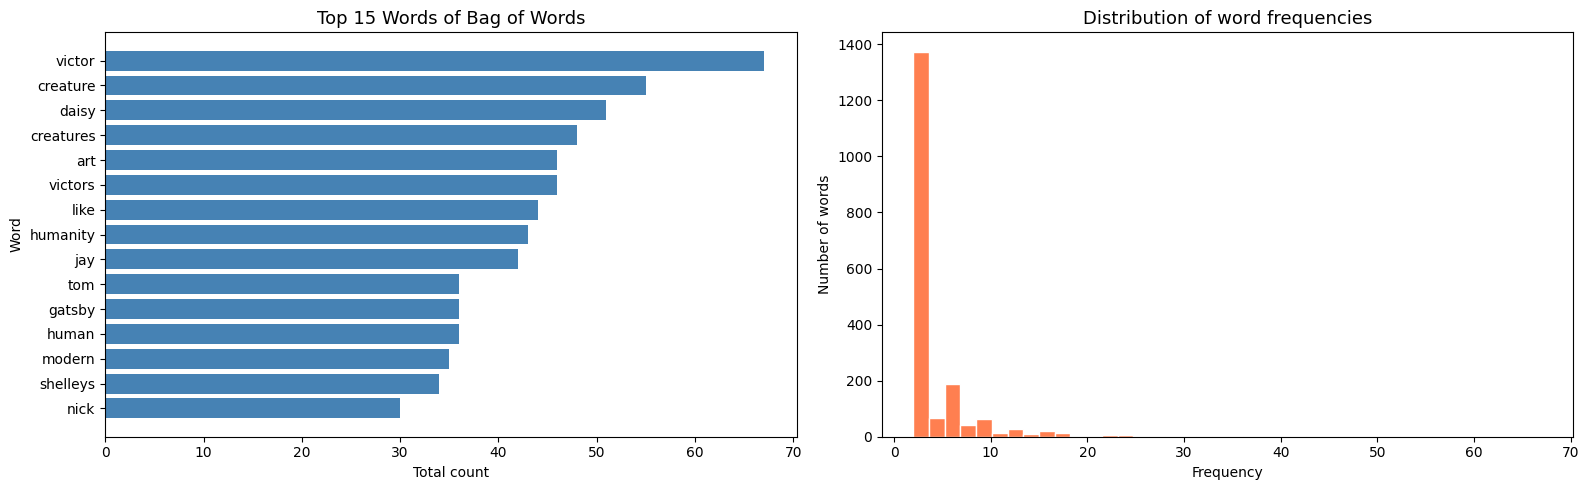

In [25]:
top15 = word_totals.head(15)
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].barh(top15.index[::-1], top15.values[::-1], color='steelblue')
axes[0].set_title('Top 15 Words of Bag of Words', fontsize=13)
axes[0].set_xlabel('Total count')
axes[0].set_ylabel('Word')

axes[1].hist(word_totals.values, bins=40, color='coral', edgecolor='white')
axes[1].set_title('Distribution of word frequencies', fontsize=13)
axes[1].set_xlabel('Frequency')
axes[1].set_ylabel('Number of words')

plt.tight_layout()
plt.show()

## #9 ##

Counts how many times each word appears. Common words that show up in every document get high raw counts even if they're not particularly meaningful or distinctive.

In [21]:
tfidf_vectorizer = TfidfVectorizer(stop_words='english')
tfidf_matrix     = tfidf_vectorizer.fit_transform(documents)

tfidf_df = pd.DataFrame(
    tfidf_matrix.toarray(),
    columns=tfidf_vectorizer.get_feature_names_out()
)
tfidf_df.index = [f'doc_{i+1}' for i in range(len(tfidf_df))]
print(f'TF-IDF shape: {tfidf_df.shape}')
tfidf_df.iloc[:3, :8]

TF-IDF shape: (100, 1855)


,abandonment,abandons,ability,abroad,accept,acceptance,access,according
doc_1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000
doc_2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000
doc_3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.079246


## #10 ##

In [23]:
tfidf_means = tfidf_df.mean(axis=0).sort_values(ascending=False)

print('Top 20 words by average TF-IDF score:')
print(tfidf_means.head(20).to_string())
print()

Top 20 words by average TF-IDF score:
victor       0.041697
creature     0.032350
daisy        0.032305
art          0.031127
creatures    0.029312
victors      0.028272
humanity     0.027132
jay          0.026404
like         0.025497
tom          0.023094
modern       0.022086
gatsby       0.021727
human        0.021521
shelleys     0.021503
fabric       0.021400
toms         0.021306
daisys       0.020259
young        0.020177
nick         0.019384
society      0.018657



## #11 ##

In [28]:
bow_top20   = set(word_totals.head(20).index)
tfidf_top20 = set(tfidf_means.head(20).index)

print('In both top20 lists:')
print(bow_top20 & tfidf_top20)
print()
print('In Bag of Words top 20 only:')
print(bow_top20 - tfidf_top20)
print()
print('In TF-IDF top 20 only:')
print(tfidf_top20 - bow_top20)

In both top20 lists:
{'daisys', 'modern', 'humanity', 'nick', 'society', 'art', 'victors', 'jay', 'creatures', 'human', 'young', 'gatsby', 'shelleys', 'toms', 'like', 'tom', 'creature', 'victor', 'daisy'}

In Bag of Words top 20 only:
{'instead'}

In TF-IDF top 20 only:
{'fabric'}


## #12 ##

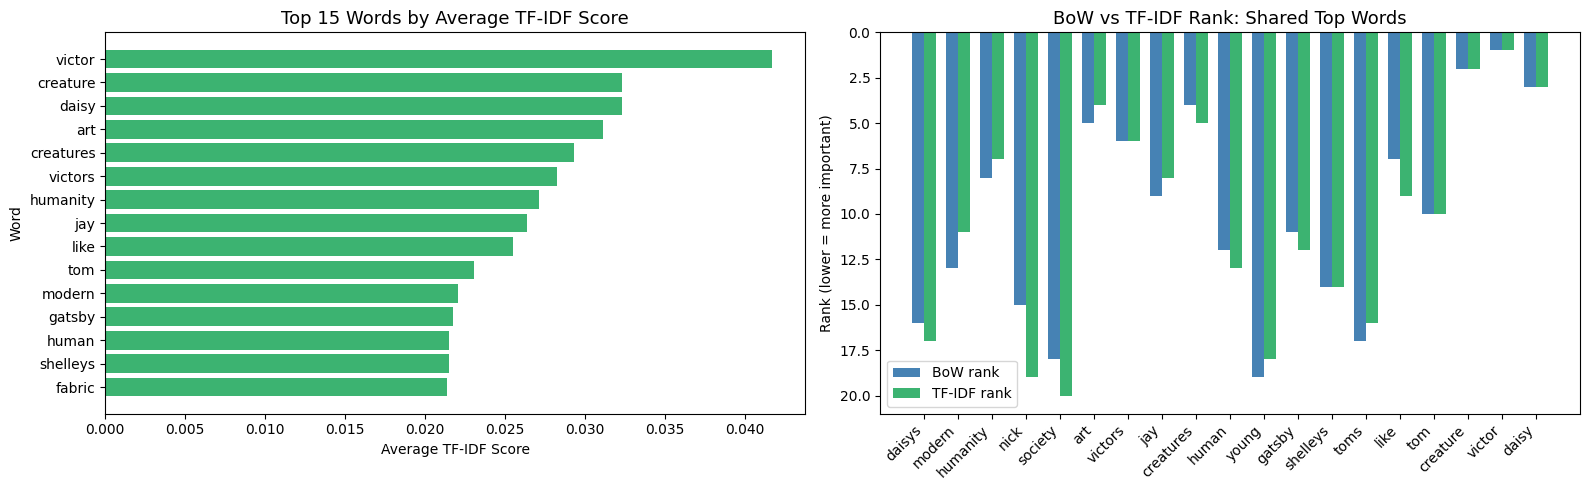

In [32]:
top15_tfidf = tfidf_means.head(15)
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].barh(top15_tfidf.index[::-1], top15_tfidf.values[::-1], color='mediumseagreen')
axes[0].set_title('Top 15 Words by Average TF-IDF Score', fontsize=13)
axes[0].set_xlabel('Average TF-IDF Score')
axes[0].set_ylabel('Word')

shared      = list(bow_top20 & tfidf_top20)
bow_ranks   = [list(word_totals.index).index(w)+1 for w in shared]
tfidf_ranks = [list(tfidf_means.index).index(w)+1 for w in shared]
x = np.arange(len(shared))
width = 0.35
axes[1].bar(x - width/2, bow_ranks,   width, label='BoW rank',    color='steelblue')
axes[1].bar(x + width/2, tfidf_ranks, width, label='TF-IDF rank', color='mediumseagreen')
axes[1].set_xticks(x)
axes[1].set_xticklabels(shared, rotation=45, ha='right')
axes[1].set_title('BoW vs TF-IDF Rank: Shared Top Words', fontsize=13)
axes[1].set_ylabel('Rank (lower = more important)')
axes[1].legend()
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

## #13 ##

High frequency Bag of Words words cluster around the central subjects of each essay: victor, creature, daisy, art, language, humanity. These reveal which characters and concepts anchor the writing. The words scoring high in TF-IDF but low in BoW are distinctive to individual essays. For example, jeans, denim, tiger, minhwa are unique to the Triptych, while clones, deferrals, hailsham are unique to the Never Let Me Go comparison. Words like humanity, redemption, fate, and agency appear across all essays, suggesting the writing consistently focuses on large philosophical questions.